In [1]:
import pandas as pd
import torch
import transformers
import numpy as np
import time
from tqdm import tqdm_notebook as tqdm

In [2]:
import pickle as pkl

In [3]:
with open('tweets.pkl', 'rb') as p:
    tweets = pkl.load(p)

In [4]:
keywords = ['vaccine', 'vax', 'anti-vax', 'antivax', 'antivaxx', 'covid', 'covid19', 'coronavirus', 'sars-cov-2']
then = time.time()

filtered_tweets = []
for tweet in tweets:
    if any(x in tweet for x in keywords):
        filtered_tweets.append(tweet)
        
now = time.time()

print(f'Found {len(filtered_tweets)} hits in {len(tweets)} tweets, took {now-then:.2} seconds')

Found 14024 hits in 879037 tweets, took 2.1 seconds


In [5]:
tweets[0]
len(tweets)

879037

In [13]:
import json

tweets_list = []
for i in tweets:
    for j in i:
        tweets_list.append([d['text'] for d in j['data']])

TypeError: string indices must be integers

In [ ]:
flat_list = [item for sublist in tweets_list for item in sublist]

In [6]:
tweets_final = list(set(filtered_tweets))

In [7]:
len(tweets_final)

11594

In [8]:
from transformers import pipeline
classifier = pipeline("zero-shot-classification", model="digitalepidemiologylab/covid-twitter-bert-v2-mnli")

In [9]:
sequence_to_classify = 'To stop the pandemic it is important that everyone turns up for their shots.'
candidate_labels = ['pro-vax', 'anti-vax']
hypothesis_template = 'This example is {}.'
classifier(tweets_final[4], candidate_labels, hypothesis_template=hypothesis_template, multi_class=True)

The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


{'sequence': 'RT @CP24: Toronto police advise hospital workers not to wear scrubs to work this weekend ahead of planned anti-vaccine trucker protest in d…',
 'labels': ['anti-vax', 'pro-vax'],
 'scores': [0.7922458052635193, 0.010013904422521591]}

In [10]:
classify_list = []

for i in tqdm(range(len(tweets_final))):
    classify_list.append(classifier(tweets_final[i], candidate_labels, hypothesis_template=hypothesis_template, multi_class=True))

/opt/anaconda3/envs/nlp/lib/python3.7/site-packages/ipykernel_launcher.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  This is separate from the ipykernel package so we can avoid doing imports until


  0%|          | 0/11594 [00:00<?, ?it/s]

The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transf

The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transf

The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transf

...

The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transf

The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transf

The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transf

The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transf

The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transformers.
The `multi_class` argument has been deprecated and renamed to `multi_label`. `multi_class` will be removed in a future version of Transf

In [11]:
scores_list = []
for i in classify_list:
    scores_list.append(i['scores'])

In [12]:
threshold = 0.20

threshold_list = []
for n, i in enumerate(scores_list):
    for j in i:
        if j>threshold:
            threshold_list.append(n)

In [13]:
len(threshold_list)/len(classify_list)

0.5969466965671899

In [14]:
threshold = 0.30

threshold_list = []
for n, i in enumerate(scores_list):
    for j in i:
        if j>threshold:
            threshold_list.append(n)
            
len(threshold_list)/len(classify_list)

0.4471278247369329

In [15]:
threshold = 0.40

threshold_list = []
for n, i in enumerate(scores_list):
    for j in i:
        if j>threshold:
            threshold_list.append(n)
            
len(threshold_list)/len(classify_list)

0.3408659651543902

In [16]:
threshold = 0.50

threshold_list = []
for n, i in enumerate(scores_list):
    for j in i:
        if j>threshold:
            threshold_list.append(n)
            
len(threshold_list)/len(classify_list)

0.27057098499223736

In [17]:
threshold = 0.60

threshold_list = []
for n, i in enumerate(scores_list):
    for j in i:
        if j>threshold:
            threshold_list.append(n)
            
len(threshold_list)/len(classify_list)

0.211402449542867

In [18]:
threshold = 0.70

threshold_list = []
for n, i in enumerate(scores_list):
    for j in i:
        if j>threshold:
            threshold_list.append(n)
            
len(threshold_list)/len(classify_list)

0.16016905295842676

# Statistic by setting threshold for average number of samples

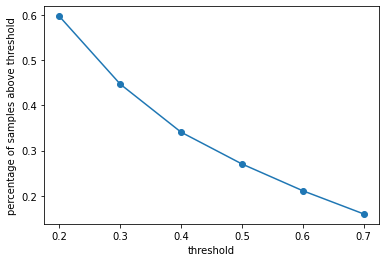

In [24]:
import matplotlib.pyplot as plt
x1, y1 = [0.5969466965671899, 0.4471278247369329, 0.3408659651543902, 0.27057098499223736, 0.211402449542867, 0.16016905295842676], [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
plt.plot(y1, x1, marker = 'o')
plt.xlabel('threshold')
plt.ylabel('percentage of samples above threshold') 
plt.show()

# Qualitative analysis
#### Based on manual inspection of 10 tweets, we find that that humans had 100% alignment with the models output

In [21]:
classify_list[50:100]

[{'sequence': 'RT @globeandmail: The ivermectin mess: People are embracing a dangerous livestock drug, while rejecting vaccines https://t.co/f5nAAbMgVy',
  'labels': ['anti-vax', 'pro-vax'],
  'scores': [0.982551097869873, 0.011767139658331871]},
 {'sequence': 'RT @tylerwatt90: Nurses and healthcare workers being deployed to the ICU should have their second vaccine. They should not have to wait 4 m…',
  'labels': ['pro-vax', 'anti-vax'],
  'scores': [0.3165850043296814, 0.1507280170917511]},
 {'sequence': 'The truth is, covid, and its economic impacts have been mismanaged, and many are rightfully angry. While continuing our mutual aid work, our efforts at climate and racial justice, substantial land back and an end to colonialism...',
  'labels': ['anti-vax', 'pro-vax'],
  'scores': [0.026120759546756744, 0.010360111482441425]},
 {'sequence': 'If you have submitted your out of province or country COVID-19 immunizations records, please allow 10 business days for the record to be updated

In [22]:
# 1
# 1
# 1
# 0
# 0
# 0
# 1
# 0
# 0
# 1